# Customer Segmentation Project using K-Means Clustering.

Business problem:

A company has customer data such as:

* Age
* Annual Income
* Spending Score

The company wants to divide customers into groups so it can create different marketing strategies for each group.

For example:

* 💰 High income + high spending → Premium customers
* 💰 High income + low spending → Potential customers
* 💸 Low income + high spending → Careless/high-value opportunity
* 💸 Low income + low spending → Low-priority customers

This is a perfect K-Means project because we don't have predefined labels. We want the algorithm to discover the groups itself.

In [2]:
import numpy as np # Numerical operations
import pandas as pd # Data manipulation
import matplotlib.pyplot as plt # Visualization
import seaborn as sns # Better visualizations

from sklearn.cluster import KMeans # Clustering algorithm
from sklearn.preprocessing import StandardScaler # Feature scaling

import warnings
warnings.filterwarnings("ignore")

### We'll use the famous Mall Customers dataset.

It typically contains:

* CustomerID
* Gender
* Age
* Annual Income (k$)
* Spending Score (1-100)

The important variables for our first K-Means model will be:

* Annual Income
* Spending Score

Why these two?

Because we're trying to answer:

Can we divide customers based on how much they earn and how much they spend?

In [4]:
data = pd.read_csv("Mall_Customers.csv")

In [6]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
data.shape

(200, 5)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
data.describe()    

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
data.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [13]:
# Select our features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

In [15]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


because K-Means needs the features on which it will create clusters.

We aren't giving it a target variable.

That's why K-Means is unsupervised learning.

There is no:

y

telling the algorithm:

"This customer belongs to Cluster 1."

The algorithm has to figure that out itself.

<function matplotlib.pyplot.show(close=None, block=None)>

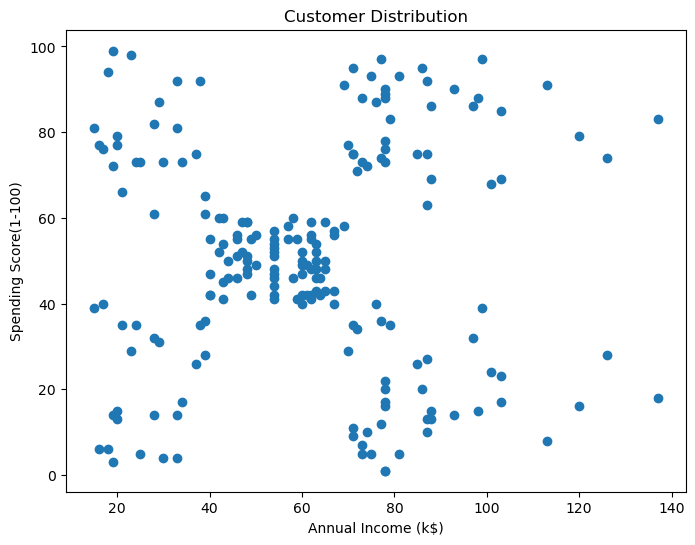

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score(1-100)')
plt.title('Customer Distribution')
plt.show

We're basically asking:

Does this data look like it naturally contains different customer groups?"

In [18]:
# Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Why scale?

Suppose we have:

* Age = 25
* Income = 100
* Spending Score = 80

Different features can have different scales.

K-Means uses distance to decide which points belong together.

Therefore, features with larger numerical ranges can influence the distance more heavily.

Scaling puts features onto a comparable scale.

In [20]:
# Elbow Method

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state = 42,
        n_init=10
    )
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

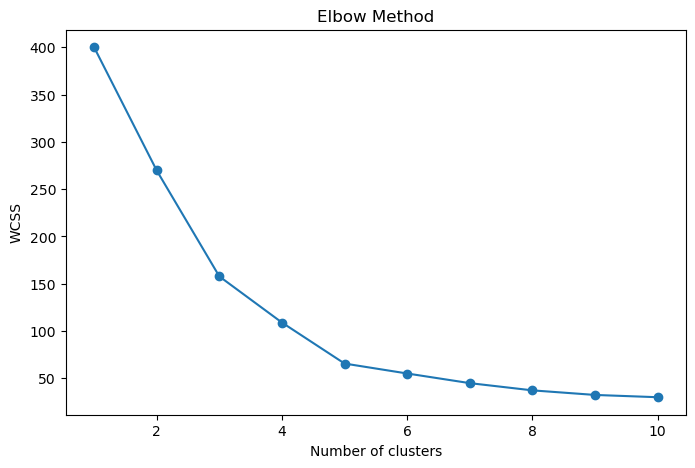

In [21]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

For this dataset, you will commonly find an elbow around:

K = 5

But do not blindly type 5.

Your graph is the thing we use to justify the choice.

In [22]:
# Build the final K-Means model

# Suppose our elbow tells us:

# K = 5

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

In [23]:
kmeans.fit(X_scaled) # train it

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [24]:
# Get the cluster labels

cluster_labels = kmeans.labels_

In [25]:
cluster_labels[:10] # Let's look at them:

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2], dtype=int32)

In [26]:
# These numbers are the cluster assignments.

In [27]:
# Add clusters to our dataset

data['Cluster'] = cluster_labels

In [28]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


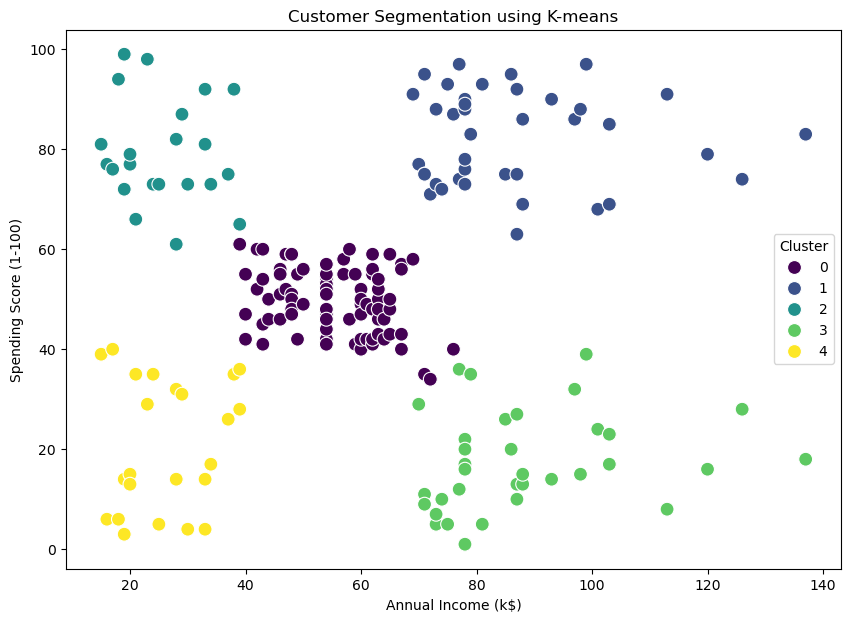

In [30]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=data,
    palette='viridis',
    s=100
)
plt.title('Customer Segmentation using K-means')
plt.show()

Understand the clusters

This is where machine learning becomes useful.

Don't just say:

"K-Means created five clusters."

We need to understand what those clusters mean.

In [35]:
data.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


The exact numbers can vary depending on the dataset/features.

Now we can give the clusters business meanings.

For example:

Cluster A

High income + high spending

Potentially:

Premium customers

Marketing strategy:

Premium products, loyalty rewards, exclusive offers.

Cluster B

High income + low spending

Potentially:

Customers with purchasing potential

Strategy:

Discounts, personalized recommendations, targeted campaigns.

Cluster C

Low income + high spending

Potentially:

High-spending customers

Strategy:

Maintain engagement and loyalty.

Cluster D

Low income + low spending

Potentially:

Low-value customers

Strategy:

Cost-effective marketing.

In [38]:
'''
Customer Segmentation using K-Means
│
├── 1. Problem Statement
│
├── 2. Import Libraries
│
├── 3. Load Dataset
│
├── 4. Understand Dataset
│   ├── shape
│   ├── info
│   ├── describe
│   └── missing values
│
├── 5. Exploratory Data Analysis
│   ├── distributions
│   └── scatter plots
│
├── 6. Feature Selection
│
├── 7. Feature Scaling
│
├── 8. Elbow Method
│
├── 9. Build K-Means Model
│
├── 10. Predict/Assign Clusters
│
├── 11. Visualization
│
├── 12. Cluster Profiling
│
└── 13. Business Insights '''

'\nCustomer Segmentation using K-Means\n│\n├── 1. Problem Statement\n│\n├── 2. Import Libraries\n│\n├── 3. Load Dataset\n│\n├── 4. Understand Dataset\n│   ├── shape\n│   ├── info\n│   ├── describe\n│   └── missing values\n│\n├── 5. Exploratory Data Analysis\n│   ├── distributions\n│   └── scatter plots\n│\n├── 6. Feature Selection\n│\n├── 7. Feature Scaling\n│\n├── 8. Elbow Method\n│\n├── 9. Build K-Means Model\n│\n├── 10. Predict/Assign Clusters\n│\n├── 11. Visualization\n│\n├── 12. Cluster Profiling\n│\n└── 13. Business Insights '